# Cursos de Machine Learning en el Sector Bancario
## Modulo 10. `Forecasting Cash Flow con Deep Learning`
                        Elaborado por: Naren Castellon

Dataset sintético para `pronóstico de flujos de caja` en bancos

- unique_id: ID de sucursal (e.g., 'Branch_1' a 'Branch_10')
- ds: Fecha diaria (timestamp)
- deposits: Depósitos diarios (y1, target principal, con tendencia, estacionalidad semanal/mensual y ruido)
- withdrawals: Retiros diarios (y2, otro target, correlacionado negativamente con depósitos para flujo neto)
- net_cash_flow: Flujo neto = deposits - withdrawals (para análisis derivado)
- interest_rate: Tasa de interés diaria (exógena, afecta depósitos)
- economic_indicator: Indicador económico sintético (e.g., GDP growth proxy, exógena)
- holiday_flag: Indicador de feriado (0/1, afecta flujos)
- day_of_week: Día de la semana (0-6, estacionalidad)
- month: Mes del año (1-12, estacionalidad anual)
- temperature: Temperatura diaria (exógena, simula impacto climático en visitas a sucursales)
- marketing_campaign: Indicador de campaña (0/1, boosts depósitos)


In [1]:
import pandas as pd  # Para manipulación de datos, creación de DataFrames y manejo de series temporales
import numpy as np   # Para generación de datos numéricos sintéticos, operaciones matemáticas y arrays
from datetime import datetime, timedelta  # Para generar fechas secuenciales diarias
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de series temporales y forecasts
import seaborn as sns  # Para gráficos avanzados en EDA, como heatmaps o distribuciones
from neuralforecast import NeuralForecast  # Librería principal para forecasting con deep learning (modelos como NHITS, NBEATS)
from neuralforecast.models import NHITS, NBEATS  # Modelos específicos: NHITS para tendencias/estacionalidad, NBEATS para descomposición
from neuralforecast.losses.pytorch import MAE  # Métrica de loss (Mean Absolute Error) para entrenamiento
from neuralforecast.losses.pytorch import GMM, MQLoss, DistributionLoss
from neuralforecast.auto import AutoNHITS  # Versión automática para tuning hiperparámetros (opcional, para profesionalismo)
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Métricas para evaluación del forecast (MAE, RMSE)
from sklearn.preprocessing import StandardScaler  # Para escalado de features exógenas (mejora estabilidad en DL)
# Utilsforecast
# ==============================================================================
from utilsforecast.plotting import plot_series
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia (e.g., deplots deprecados)



/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-15 21:02:39,001	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-15 21:02:39,230	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
cash_df = pd.read_csv('bank_cash_flow_data.csv')
cash_df

,unique_id,ds,deposits,withdrawals,net_cash_flow,interest_rate,economic_indicator,holiday_flag,day_of_week,month,temperature,marketing_campaign
0,Branch_1,2020-01-01,6063,4436,1627,0.0397,1.84,0,2,1,19.0,0
1,Branch_1,2020-01-02,6815,5036,1779,0.0296,2.19,0,3,1,17.4,0
2,Branch_1,2020-01-03,7293,6277,1016,0.0280,3.05,0,4,1,17.3,0
3,Branch_1,2020-01-04,5630,4623,1007,0.0477,2.67,0,5,1,24.4,0
4,Branch_1,2020-01-05,3486,2700,786,0.0346,2.95,0,6,1,15.3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
21915,Branch_10,2025-12-27,19817,17734,2083,0.0205,3.16,0,5,12,18.4,0
21916,Branch_10,2025-12-28,19145,17402,1743,0.0233,3.89,0,6,12,20.7,0
21917,Branch_10,2025-12-29,19397,12345,7052,0.0063,3.98,0,0,12,18.5,0
21918,Branch_10,2025-12-30,19397,13631,5766,0.0342,3.43,0,1,12,28.0,1


In [3]:
# Paso 2: Análisis Exploratorio de Datos (EDA)
# Convertir ds a datetime si no lo es
cash_df['ds'] = pd.to_datetime(cash_df['ds'])

In [4]:
# Resumen estadístico
print("\nEstadísticas descriptivas del dataset:")
print(cash_df.describe())


Estadísticas descriptivas del dataset:
                        ds      deposits   withdrawals  net_cash_flow  \
count                21920  21920.000000  21920.000000   21920.000000   
mean   2022-12-31 12:00:00  12755.290100   9581.685265    3173.604836   
min    2020-01-01 00:00:00    410.000000    162.000000   -1063.000000   
25%    2021-07-01 18:00:00   9865.750000   7251.750000    1961.000000   
50%    2022-12-31 12:00:00  12727.000000   9441.000000    2970.000000   
75%    2024-07-01 06:00:00  15650.000000  11780.000000    4202.250000   
max    2025-12-31 00:00:00  24669.000000  21317.000000    9873.000000   
std                    NaN   4039.668255   3273.342748    1611.710177   

       interest_rate  economic_indicator  holiday_flag   day_of_week  \
count   21920.000000        21920.000000  21920.000000  21920.000000   
mean        0.030125            3.002907      0.100319      2.999544   
min         0.000300            0.920000      0.000000      0.000000   
25%         0.

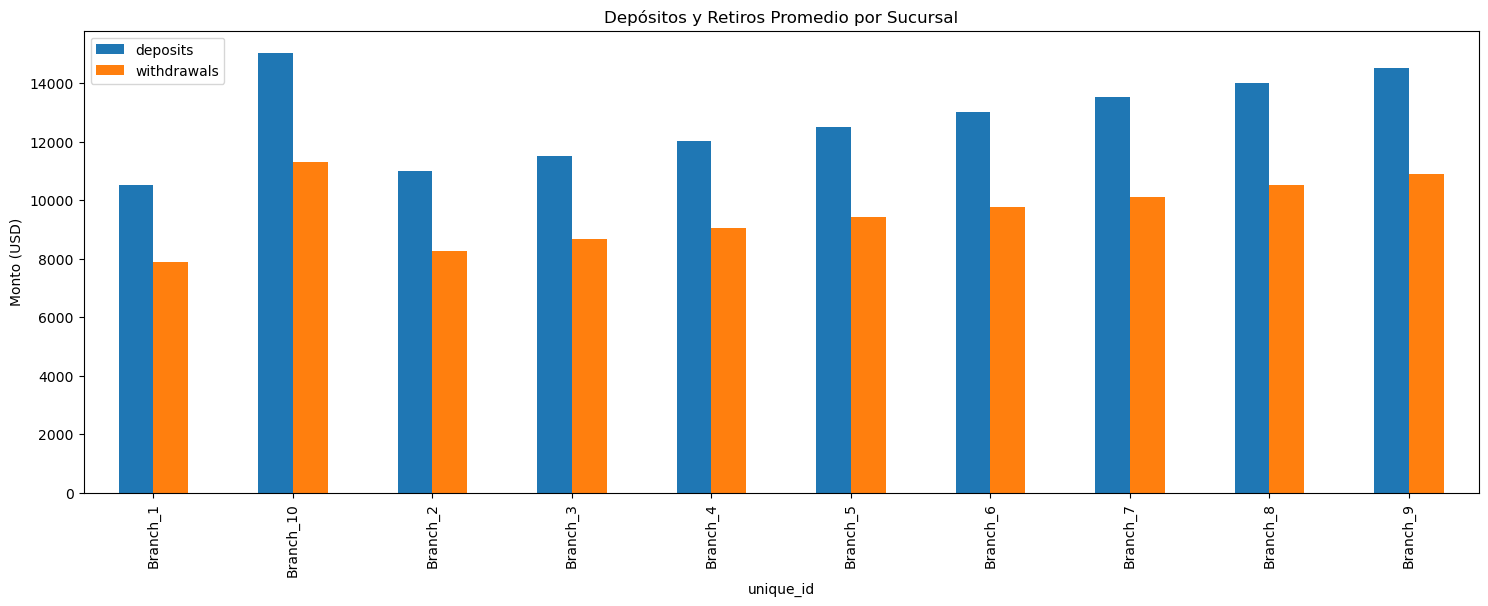

In [5]:
# Visualizar depósitos y retiros promedio por sucursal
avg_flow = cash_df.groupby('unique_id')[['deposits', 'withdrawals']].mean()
avg_flow.plot(kind='bar', figsize=(18, 6))
plt.title('Depósitos y Retiros Promedio por Sucursal')
plt.ylabel('Monto (USD)')
plt.show()

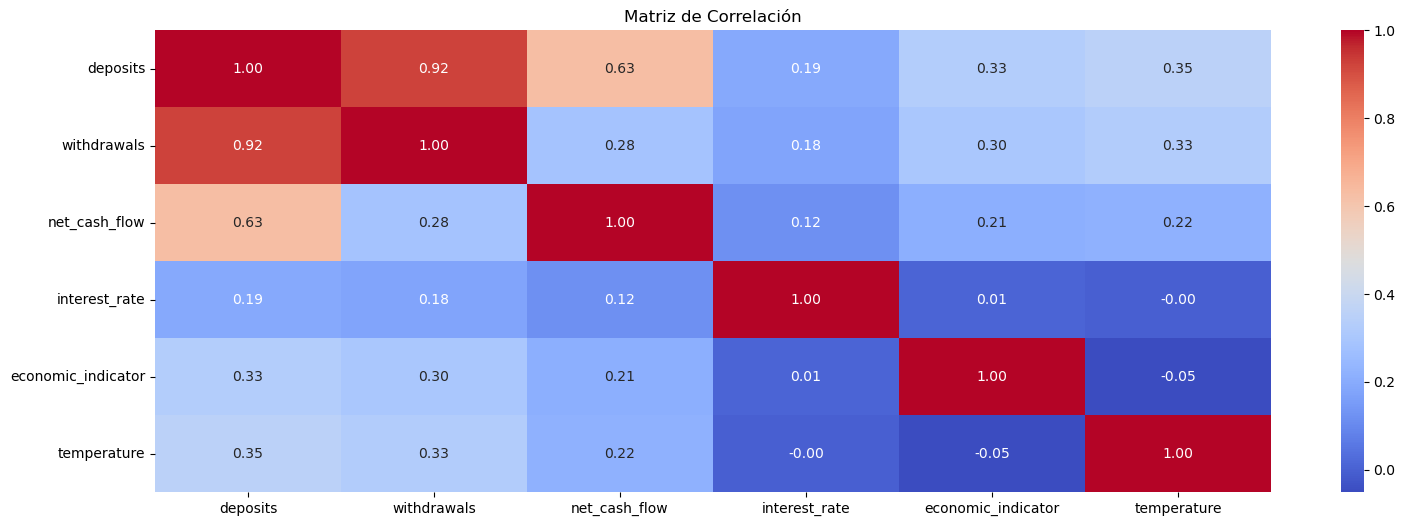

In [6]:
# Correlación entre variables numéricas
numeric_cols = ['deposits', 'withdrawals', 'net_cash_flow', 'interest_rate', 'economic_indicator', 'temperature']
corr_matrix = cash_df[numeric_cols].corr()
plt.figure(figsize=(18, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

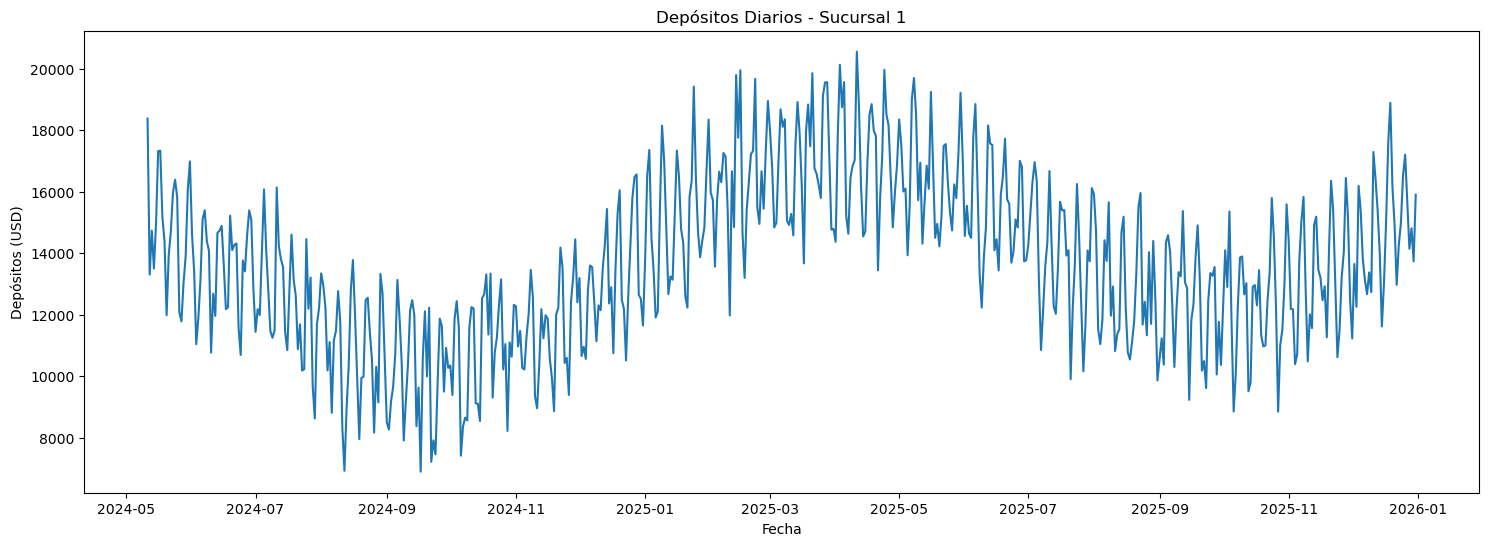

In [7]:
# Estacionalidad semanal en depósitos (ejemplo por sucursal 1)
branch1 = cash_df[cash_df['unique_id'] == 'Branch_1']
plt.figure(figsize=(18, 6))
sns.lineplot(x='ds', y='deposits', data=branch1[-600:] )
plt.title('Depósitos Diarios - Sucursal 1')
plt.xlabel('Fecha')
plt.ylabel('Depósitos (USD)')
plt.show()

In [8]:
# Paso 3: Preprocesamiento para NeuralForecast
# NeuralForecast requiere formato: unique_id (sucursal), ds (fecha), y (target, e.g., deposits)
# Para multivariado, agregamos exógenas (futuras conocidas o no)
# Aquí pronosticamos 'deposits' como y principal, con exógenas como interest_rate, holiday_flag, etc.


# Seleccionar columns para forecast
forecast_df = cash_df[['unique_id', 'ds', 'deposits', 'interest_rate', 'economic_indicator', 'holiday_flag', 'day_of_week', 'month', 'temperature', 'marketing_campaign']]
forecast_df = forecast_df.rename(columns={'deposits': 'y'})  # NeuralForecast espera 'y' como target

In [9]:
forecast_df

,unique_id,ds,y,interest_rate,economic_indicator,holiday_flag,day_of_week,month,temperature,marketing_campaign
0,Branch_1,2020-01-01,6063,0.0397,1.84,0,2,1,19.0,0
1,Branch_1,2020-01-02,6815,0.0296,2.19,0,3,1,17.4,0
2,Branch_1,2020-01-03,7293,0.0280,3.05,0,4,1,17.3,0
3,Branch_1,2020-01-04,5630,0.0477,2.67,0,5,1,24.4,0
4,Branch_1,2020-01-05,3486,0.0346,2.95,0,6,1,15.3,0
...,...,...,...,...,...,...,...,...,...,...
21915,Branch_10,2025-12-27,19817,0.0205,3.16,0,5,12,18.4,0
21916,Branch_10,2025-12-28,19145,0.0233,3.89,0,6,12,20.7,0
21917,Branch_10,2025-12-29,19397,0.0063,3.98,0,0,12,18.5,0
21918,Branch_10,2025-12-30,19397,0.0342,3.43,0,1,12,28.0,1


In [10]:
# Dividir train/test (últimos 90 días como test para validación)
train_df = forecast_df.groupby('unique_id').apply(lambda x: x.iloc[:-90]).reset_index(drop=True)
test_df = forecast_df.groupby('unique_id').apply(lambda x: x.iloc[-90:]).reset_index(drop=True)

In [11]:
train_df

,unique_id,ds,y,interest_rate,economic_indicator,holiday_flag,day_of_week,month,temperature,marketing_campaign
0,Branch_1,2020-01-01,6063,0.0397,1.84,0,2,1,19.0,0
1,Branch_1,2020-01-02,6815,0.0296,2.19,0,3,1,17.4,0
2,Branch_1,2020-01-03,7293,0.0280,3.05,0,4,1,17.3,0
3,Branch_1,2020-01-04,5630,0.0477,2.67,0,5,1,24.4,0
4,Branch_1,2020-01-05,3486,0.0346,2.95,0,6,1,15.3,0
...,...,...,...,...,...,...,...,...,...,...
21015,Branch_9,2025-09-28,15440,0.0357,3.37,0,6,9,18.1,0
21016,Branch_9,2025-09-29,13755,0.0296,2.99,0,0,9,17.3,0
21017,Branch_9,2025-09-30,14417,0.0309,3.12,1,1,9,5.0,0
21018,Branch_9,2025-10-01,15879,0.0357,3.45,0,2,10,7.7,0


In [ ]:
plot_series(train_df, max_insample_length= 100)

In [ ]:
test_df

In [ ]:
# Paso 4: Configurar y Entrenar Modelos con NeuralForecast
# Usamos NHITS (Neural Hierarchical Interpolation for Time Series) y NBEATS para ensemble
# NHITS: Bueno para estacionalidad; NBEATS: Para descomposición en trend/season
# Horizonte: 90 días (3 meses para tesorería)
# Exógenas: Todas menos y (para mejorar precisión)


models= NHITS(
            h = 250,  # Horizonte de forecast
            input_size=365,  # Ventana de input (1 año para capturar anualidad)
            loss =  MQLoss(level = [80, 95]),
            valid_loss =  MQLoss(level = [80, 95]),
            max_steps = 500,  # Iteraciones de entrenamiento
            scaler_type=  'robust', # 'robust', 'standard',  
            futr_exog_list = ['interest_rate', 'economic_indicator', 'holiday_flag', 'day_of_week', 'month', 'temperature', 'marketing_campaign'],  # Exógenas futuras
            hist_exog_list = ['interest_rate', 'economic_indicator', 'holiday_flag', 'day_of_week', 'month', 'temperature', 'marketing_campaign'],
            early_stop_patience_steps = 10,  # Add early stopping
            n_blocks=[2, 2, 2],  # Default blocks
            mlp_units=[(128, 128)],  # Add explicit MLP units for capacity
            n_freq_downsample=[4, 2, 1],  # Adjusted for multi-scale
            learning_rate=1e-3,
            valid_batch_size=8,  # Increased for stability
            inference_windows_batch_size=4,  # Increased for faster inference
        )

In [ ]:
nf = NeuralForecast(models = [models], freq = 'D')

In [ ]:
train_df[-90:]

In [ ]:
train_df[:-90]

In [ ]:
# Entrenar modelos
print("Entrenando modelos con NeuralForecast...")
nf.fit(df = train_df, val_size = 260)

In [12]:
# Paso 5: Generar Pronósticos
# Simular exógenas futuras (en real, usar pronósticos o conocidas como holidays)
futr_df = pd.DataFrame()
for uid in train_df['unique_id'].unique():
    last_row = train_df[train_df['unique_id'] == uid].iloc[-1]
    futr_dates = pd.date_range(start=last_row['ds'] + timedelta(days=1), periods=250, freq='D')
    futr_rows = pd.DataFrame({
        'unique_id': [uid] * 250,
        'ds': futr_dates,
        'interest_rate': np.random.uniform(0.01, 0.05, 250),  # Simulado
        'economic_indicator': np.random.normal(2.5, 0.5, 250),
        'holiday_flag': np.random.choice([0, 1], 250, p=[0.9, 0.1]),
        'day_of_week': futr_dates.weekday,
        'month': futr_dates.month,
        'temperature': 20 + 10 * np.sin(2 * np.pi * (futr_dates.dayofyear / 365)) + np.random.normal(0, 5, 250),
        'marketing_campaign': np.random.choice([0, 1], 250, p=[0.8, 0.2])
    })
    futr_df = pd.concat([futr_df, futr_rows])

futr_df.to_csv('Cash_future.csv', index= False)

In [ ]:
# Pronosticar
forecasts = nf.predict(futr_df = futr_df, )
forecasts

In [ ]:
plot_series(forecast_df, forecasts, max_insample_length= 200)

In [ ]:
test_df

In [ ]:
forecasts

In [ ]:
# Paso 6: Evaluación del Forecast
# Unir test y forecasts para métricas
#forecasts = forecasts.  # Reset para merge
test_df = test_df.merge(forecasts[['unique_id', 'ds', 'NHITS-median']], on=['unique_id', 'ds'], how='left')

In [ ]:
# Métricas por modelo (MAE, RMSE para cada sucursal y promedio)
metrics = {}
for model_name in ['NHITS-median']:
    mae = mean_absolute_error(test_df['y'], test_df[model_name])
    rmse = np.sqrt(mean_squared_error(test_df['y'], test_df[model_name]))
    metrics[model_name] = {'MAE': mae, 'RMSE': rmse}

print("\nMétricas de Evaluación:")
print(pd.DataFrame(metrics))

# Visualizar forecast vs real para sucursal ejemplo
example_branch = 'Branch_1'
branch_test = test_df[test_df['unique_id'] == example_branch]
plt.figure(figsize=(12, 6))
plt.plot(branch_test['ds'], branch_test['y'], label='Real', marker='o')
plt.plot(branch_test['ds'], branch_test['NHITS-median'], label='NHITS Forecast', linestyle='--')
#plt.plot(branch_test['ds'], branch_test['NBEATS'], label='NBEATS Forecast', linestyle='--')
plt.title(f'Pronóstico de Depósitos - {example_branch}')
plt.xlabel('Fecha')
plt.ylabel('Depósitos (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:








# Paso 7: Análisis y Uso para Tesorería
# Agregar flujo neto pronosticado (simulando retiros forecast similar, pero enfocado en depósitos)
# En real, modelar retiros como otro target
forecasts['forecast_net'] = forecasts['NHITS-median'] - (forecasts['NHITS-median'] * np.random.uniform(0.6, 0.9))  # Simulado

# Resumen por sucursal: Flujo acumulado pronosticado
cum_flow = forecasts.groupby('unique_id')['forecast_net'].sum().reset_index(name='Cumulative_Net_Flow')
print("\nFlujo de Caja Pronosticado Acumulado por Sucursal (90 días):")
print(cum_flow)

print("\n¡Pronóstico de Flujos de Caja completado con NeuralForecast! Ayuda a tesorería en liquidez, inversiones y riesgos.")
print("- NHITS/NBEATS: Modelos DL que capturan no-linealidades mejor que clásicos como ARIMA.")
print("- Exógenas: Mejoran precisión al incluir factores externos (e.g., holidays boost depósitos).")
print("- Recomendación: En producción, usa AutoNHITS para tuning automático; integra con APIs para exógenas reales (e.g., tasas de interés).")

In [ ]:
cash_df.iloc[:-20]

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta

def generar_futuro(train_df, periods=250):
    """
    Genera un DataFrame con fechas futuras y variables simuladas
    para cada unique_id en train_df.

    Parámetros:
    -----------
    train_df : pd.DataFrame
        DataFrame de entrenamiento con columnas ['unique_id', 'ds'].
    periods : int, opcional (default=250)
        Número de días futuros a generar.

    Retorna:
    --------
    futr_df : pd.DataFrame
        DataFrame con las fechas futuras y variables simuladas.
    """
    futr_df = pd.DataFrame()

    for uid in train_df['unique_id'].unique():
        # Última fila de cada serie
        last_row = train_df[train_df['unique_id'] == uid].iloc[-1]

        # Fechas futuras
        futr_dates = pd.date_range(
            start=last_row['ds'] + timedelta(days=1),
            periods=periods,
            freq='D'
        )

        # Variables simuladas
        futr_rows = pd.DataFrame({
            'unique_id': [uid] * periods,
            'ds': futr_dates,
            'interest_rate': np.random.uniform(0.01, 0.05, periods),
            'economic_indicator': np.random.normal(2.5, 0.5, periods),
            'holiday_flag': np.random.choice([0, 1], periods, p=[0.9, 0.1]),
            'day_of_week': futr_dates.weekday,
            'month': futr_dates.month,
            'temperature': 20 + 10 * np.sin(2 * np.pi * (futr_dates.dayofyear / 365)) 
                           + np.random.normal(0, 5, periods),
            'marketing_campaign': np.random.choice([0, 1], periods, p=[0.8, 0.2])
        })

        # Concatenar resultados
        futr_df = pd.concat([futr_df, futr_rows], ignore_index=True)

    return futr_df


In [ ]:
# Generar 100 días futuros
futuro = generar_futuro(train_df.iloc[-90:], periods=600)

futuro


In [ ]:
train_deposits = deposits_df.copy()
            st.dataframe(generar_futuro(train_deposits, 30))
            #nf_deposits = train_neural_forecast(train_deposits)
            #futr_deposits = deposits_df.iloc[-horizon:].drop(columns=['y'])  # Simula exógenas futuras (en real, pronostica o conoce)
            futr_deposits = generar_futuro(train_deposits.iloc[-horizon:] , periods = horizon)
            st.dataframe(futr_deposits)
            #futr_deposits = futr_deposits.drop(columns=['y'])
            #forecast_deposits = nf_deposits.predict(futr_df=futr_deposits)

In [ ]:
# Pronosticar retiros
            withdrawals_df = forecast_df_branch.rename(columns={'withdrawals': 'y'}).drop(columns=['deposits'])
            #train_withdrawals = withdrawals_df.iloc[:-horizon]
            train_withdrawals = withdrawals_df.copy()
            #nf_withdrawals = train_neural_forecast(train_withdrawals)

            # generar valores futuros
            futr_withdrawals = generar_futuro(train_withdrawals.iloc[-horizon:] , periods = horizon)
            #futr_withdrawals = withdrawals_df.drop(columns=['y'])
            #forecast_withdrawals = nf_withdrawals.predict(futr_df = futr_withdrawals)